In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Dataset .csv to Dataset .csv


In [ ]:
df = pd.read_csv(next(iter(uploaded)))

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
print(df.shape)

df.info()

df.describe()


(9551, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to 

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [ ]:
# Fill numerical columns with median

numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)


# Fill categorical columns with mode

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning")

print(df.isnull().sum())

Missing Values After Cleaning
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [ ]:
drop_columns = [
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality',
    'Locality Verbose'
]

for col in drop_columns:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [ ]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,162,73,121.027535,14.565443,920,1100,0,1,0,0,0,3,4.8,0,1,314
1,162,73,121.014101,14.553708,1111,1200,0,1,0,0,0,3,4.5,0,1,591
2,162,75,121.056831,14.581404,1671,4000,0,1,0,0,0,4,4.4,1,5,270
3,162,75,121.056475,14.585318,1126,1500,0,0,0,0,0,4,4.9,0,1,365
4,162,75,121.057508,14.584450,1122,1500,0,1,0,0,0,4,4.8,0,1,229


In [ ]:
X = df.drop("Aggregate rating", axis=1)

y = df["Aggregate rating"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
linear_predictions = linear_model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, linear_predictions)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, linear_predictions)

r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

Linear Regression Results
MAE : 0.9502546967312137
MSE : 1.2956118008713287
RMSE : 1.1382494458032162
R2 Score : 0.4307777850764678


In [ ]:
tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
tree_predictions = tree_model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, tree_predictions)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, tree_predictions)

r2 = r2_score(y_test, tree_predictions)

print("Decision Tree Results")

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

Decision Tree Results
MAE : 0.14903192046049188
MSE : 0.053867085295656716
RMSE : 0.23209283766557018
R2 Score : 0.9763336968813904


In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree"
    ],

    "R2 Score":[

        r2_score(y_test, linear_predictions),

        r2_score(y_test, tree_predictions)

    ]
})

comparison

,Model,R2 Score
0,Linear Regression,0.430778
1,Decision Tree,0.976334


In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": tree_model.feature_importances_

})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
14,Votes,0.899965
12,Rating color,0.081987
13,Rating text,0.007401
2,Longitude,0.003218
3,Latitude,0.003011
4,Cuisines,0.001797
5,Average Cost for two,0.001715
8,Has Online delivery,0.000328
1,City,0.000233
11,Price range,0.000166


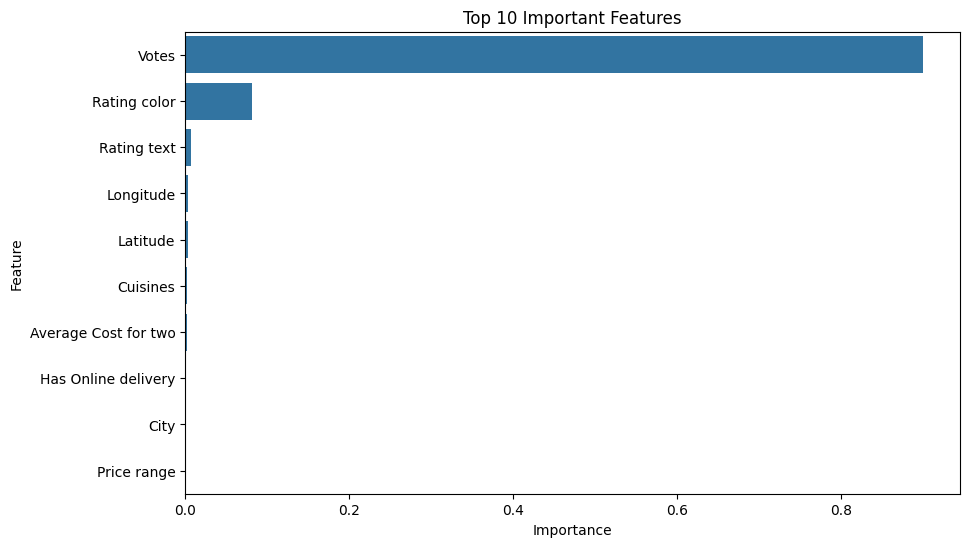

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=importance.head(10)

)

plt.title("Top 10 Important Features")

plt.show()

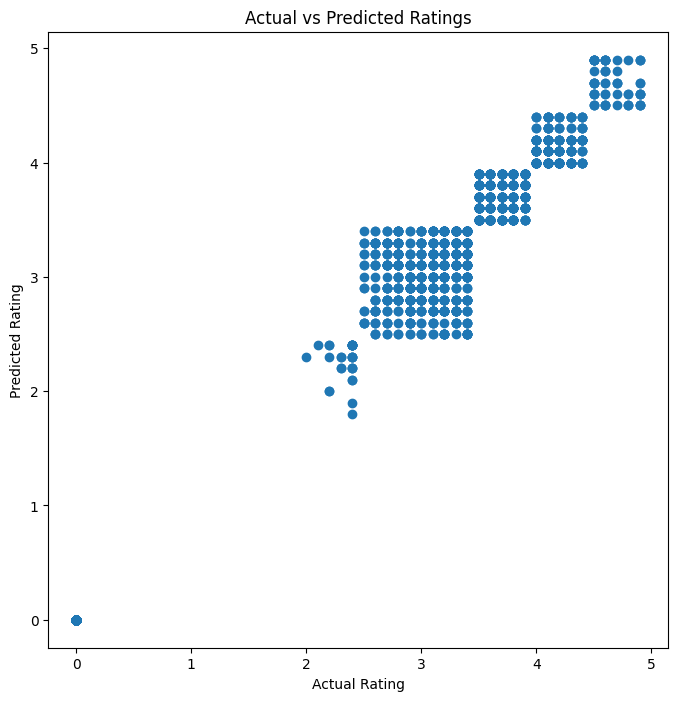

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, tree_predictions)

plt.xlabel("Actual Rating")

plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings")

plt.show()

In [ ]:
import joblib

joblib.dump(tree_model, "Restaurant_Rating_Model.pkl")

['Restaurant_Rating_Model.pkl']